<a href="https://colab.research.google.com/github/AbhinavDharam/Netflix-Content-Strategy-Viewer-Preference-Analysis/blob/main/Director_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving cleaned_netflix_data.csv to cleaned_netflix_data.csv


In [ ]:
df = pd.read_csv('cleaned_netflix_data.csv')

In [ ]:
df['director_list'] = df['director'].apply(lambda x: [i.strip() for i in x.split(',')] if x != 'Unknown' else [])
df['genre_list'] = df['listed_in'].apply(lambda x: [i.strip() for i in x.split(',')])

In [ ]:
director_df = df.explode('director_list')
director_df = director_df[director_df['director_list'].notna()]
director_df = director_df[director_df['director_list'] != '']

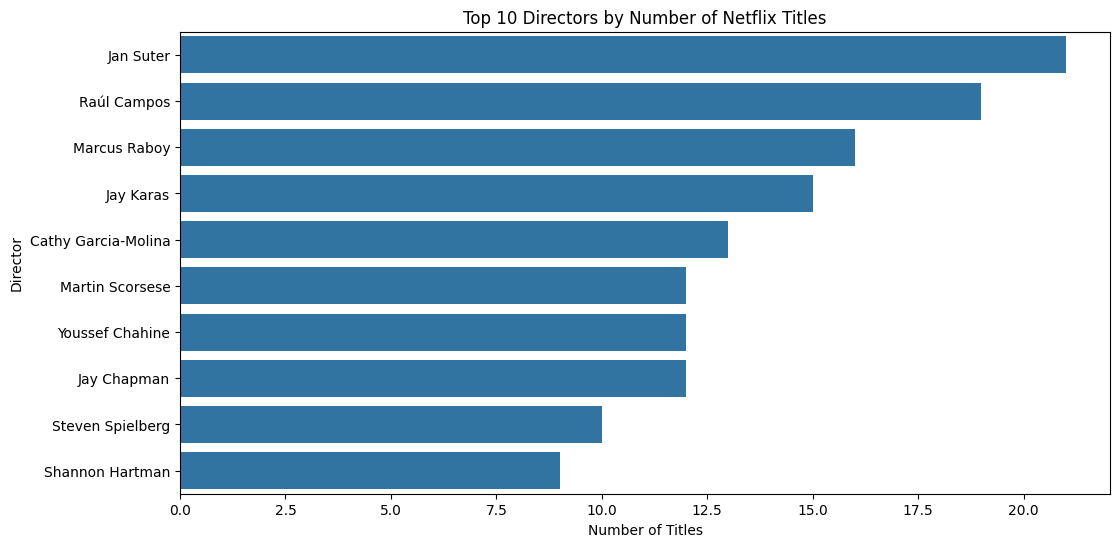

In [ ]:
#Top Directors by Titles
top_directors = director_df['director_list'].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_directors.values, y=top_directors.index)
plt.title("Top 10 Directors by Number of Netflix Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Director")
plt.show()

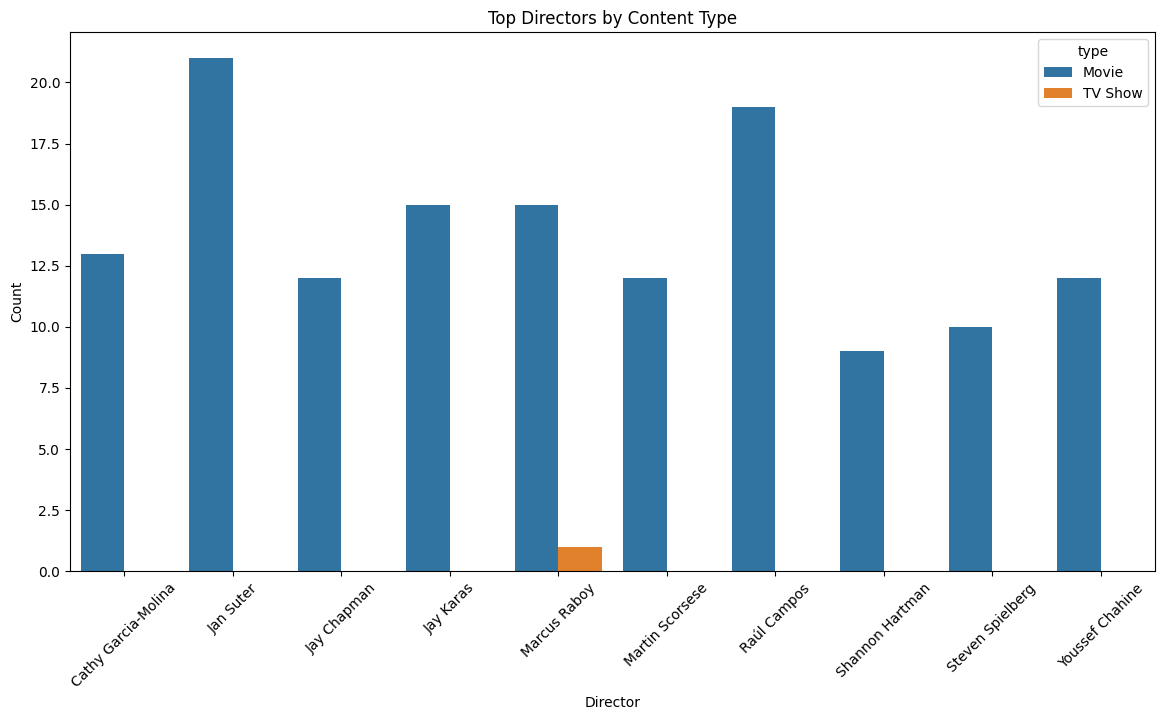

In [ ]:
#Director by Content type
director_type = director_df.groupby(['director_list', 'type']).size().reset_index(name='count')

top_director_names = director_df['director_list'].value_counts().head(10).index
director_type_top = director_type[director_type['director_list'].isin(top_director_names)]

plt.figure(figsize=(14,7))
sns.barplot(data=director_type_top, x='director_list', y='count', hue='type')
plt.xticks(rotation=45)
plt.title("Top Directors by Content Type")
plt.xlabel("Director")
plt.ylabel("Count")
plt.show()

In [ ]:
#Directors-genre combinations
director_genre_df = df.explode('director_list').explode('genre_list')
director_genre_df = director_genre_df[director_genre_df['director_list'] != 'Unknown']

director_genre_counts = director_genre_df.groupby(['director_list', 'genre_list']).size().reset_index(name='count')
director_genre_counts = director_genre_counts.sort_values('count', ascending=False)

print(director_genre_counts.head(15))

             director_list            genre_list  count
4069             Jan Suter       Stand-Up Comedy     21
8042           Raúl Campos       Stand-Up Comedy     19
6036          Marcus Raboy       Stand-Up Comedy     15
4171             Jay Karas       Stand-Up Comedy     14
1652   Cathy Garcia-Molina  International Movies     13
4162           Jay Chapman       Stand-Up Comedy     12
10556      Youssef Chahine                Dramas     12
10557      Youssef Chahine  International Movies     11
6189       Martin Scorsese                Dramas     10
9011       Shannon Hartman       Stand-Up Comedy      9
1651   Cathy Garcia-Molina                Dramas      9
2289          David Dhawan              Comedies      9
1653   Cathy Garcia-Molina       Romantic Movies      8
2291          David Dhawan  International Movies      8
10555      Youssef Chahine        Classic Movies      8
